In [2]:
import sys
import importlib
def reload_modules(*modules):
    for module in modules:
        if module.__name__ in sys.modules:
            importlib.reload(module)
        else:
            print(f"Module {module.__name__} is not currently imported.")

import numpy as np
import time
import copy
from PIL import Image
import cv2
import open3d as o3d
import importlib
import imutils
import matplotlib.pyplot as plt
from magpie_perception import pcd
from magpie_perception import utils
from magpie_perception.utils import label_wrist_image, find_object, label_wrist_image_rotation_axes
from magpie_control import realsense_wrapper as real
from magpie_control import ur5
from magpie_control import gripper
from magpie_control import poses
from magpie_control import utils as control_utils
import spatialmath as sm
reload_modules(pcd, utils, real, ur5, gripper, control_utils)
from magpie_control.utils import transform_6d

# rerun viz
import rerun as rr
from rerun_rlds_ur5.rlds import RLDSDataset, DeliGraspTrajectory, LiveRobotData
from rerun_rlds_ur5.rerun_loader_urdf import URDFLogger, get_urdf_paths, update_urdf
reload_modules(LiveRobotData, URDFLogger)
ur5_urdf, _, _= get_urdf_paths("ur5")
rr.init("ScalingForce-visualized", spawn=True)
urdf_logger = URDFLogger(ur5_urdf)
urdf_logger.log()
rr.log("annotation", rr.TextDocument("annotation_1",media_type="text/markdown"))
viz_joints = False
rerun_viz = LiveRobotData(entity_to_transform=urdf_logger.entity_to_transform, visualize_joints=viz_joints)
rr.send_blueprint(rerun_viz.blueprint())

# with help from: https://github.com/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb
import os
from google import genai
import openai
from dotenv import load_dotenv
import instructor
from magpie_prompts.prompts import sf_force_thinker, sf_grasp_selection, sf_force_reflection, sf_position_thinker
from magpie_prompts import conversation
from magpie_prompts.conversation import openai_encode_image, build_messages, send_message
reload_modules(sf_force_thinker, sf_grasp_selection, sf_position_thinker, conversation, sf_force_reflection)

load_dotenv()
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
OPENAI_API_KEY = os.getenv('CORRELL_API_KEY')
GEMINI_MODEL_ID = "gemini-2.0-flash" # @param ["gemini-1.5-flash-latest","gemini-2.0-flash-lite","gemini-2.0-flash","gemini-2.5-pro-exp-03-25"] {"allow-input":true}
# OPENAI_MODEL_ID = "gpt-4o-mini"
OPENAI_MODEL_ID = "gpt-4.1-mini"

gemini_client = genai.Client(api_key=GEMINI_API_KEY)
openai_client = openai.OpenAI(api_key=OPENAI_API_KEY)
force_thinker = sf_force_thinker.PromptForceThinker()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[Open3D INFO] Resetting default logger to print to terminal.
Module LiveRobotData is not currently imported.
Module URDFLogger is not currently imported.


[2025-04-21T23:15:08Z INFO  re_sdk::spawn] A process is already listening at this address. Assuming it's a Rerun Viewer. addr=0.0.0.0:9876


In [2]:
from magpie_perception.label import Label
from magpie_perception.label_owlvit import LabelOWLViT
from magpie_perception.label_owlv2  import LabelOWLv2
from magpie_perception.label_dino   import LabelDINO
from magpie_perception.mask_sam2    import MaskSAM2

label_models = {'owl-vit': LabelOWLViT(),
                'owl-v2':  LabelOWLv2(),
                'dino':    LabelDINO(),}
mask_models = {'mask': MaskSAM2(),
               'box-dbscan': None}
label_model = label_models['owl-vit']
label_model = label_models['owl-v2']
label_model.init()

/home/will/miniconda3/envs/octo/lib/python3.10/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [3]:
devices = real.poll_devices()
print(devices)
wrist = real.RealSense(fps=15, w=640, h=480, device_name="D405")
wrist.initConnection(device_serial=devices['D405'])
wkspc = real.RealSense(zMax=5, fps=6, w=640, h=480, device_name="D435")
wkspc.initConnection(device_serial=devices['D435'])

{'D435': '832412070344', 'D405': '126122270157'}
There are 2 available devices!
There are 2 available devices!


# Grasp Localization and Initial Motion

In [268]:
user_query = "push the wheeled chair forward"
user_query = "open the blue case"
# user_query = "tip the bottle forward onto its edge"
# user_query = "push the bottle 10 cm forward"
# user_query = "close the blue case"
user_query = "turn the black wheeled chair to face forward"

model_type = "gemini"
# model_type = "openai"
client, model = None, None
if model_type == "openai":
    client = openai_client
    model = "gpt-4.1-mini"
    # model = OPENAI_MODEL_ID
elif model_type == "gemini":
    client = gemini_client
    model = GEMINI_MODEL_ID

direction_dict = {
    "up": "positive +Z",
    "down": "negative -Z",
    "left": "positive +X",
    "right": "negative -X",
    "forward": "negative -Y",
    "backward": "positive -Y",
}

# SAVE = False
SAVE = True
STEP = 0
log_time = time.time()
LOAD = False
if not LOAD:
    LOG_NAME = f"scalingforce/{user_query}_log_{log_time}"
else:
    LOG_NAME = f"scalingforce/tip the bottle onto its edge_log_1744833659.8022175"
    episode_name = f"{LOG_NAME}/episode_0_1744834691.0252757"
if not os.path.exists(LOG_NAME):
    os.makedirs(LOG_NAME)
MESSAGES, RESPONSES, MOTION_PLANS, MOTION_REPORTS = [], [], [], []

In [255]:
pcd_wrist, rgbd_wrist = wrist.getPCD()
pcd_wkspc, rgbd_wkspc = wkspc.getPCD()

img_wrist = np.array(rgbd_wrist.color).copy()
img_wkspc = np.array(rgbd_wkspc.color)

grasp_prompt = sf_grasp_selection.grasp_prompt.format(**{"user_query": user_query})
img = Image.fromarray(img_wrist)
image_response = gemini_client.models.generate_content(
    model=GEMINI_MODEL_ID,
    contents=[grasp_prompt, img],
)
# image_response = send_message(gemini_client, model=GEMINI_MODEL_ID, messages=[grasp_prompt, img], model_type="gemini")
grasp_phrase = image_response.text.split("\n")[-1].split(": ")[-1]
print(grasp_phrase)


Textured black seat rim


In [ ]:
query = [grasp_phrase]
seg_type = 'box-dbscan'
mask_model = mask_models[seg_type]
pcd_wrist, rgbd_wrist = wrist.getPCD()
pose, pred_image = find_object(rgbd_wrist, query, label_model, mask_model, seg_type, wrist)
np.save(f"{LOG_NAME}/init_moveto_pose.npy", pose)
print(pose)
print(plt.get_backend())
%matplotlib inline
plt.imshow(pred_image)
plt.axis('off')  # Optional: to hide axis values and ticks
plt.show()

In [6]:
ROBOT_IP = "192.168.0.4"
robot = ur5.UR5_Interface(ROBOT_IP, 
                            freq=6, # 6Hz frequency
                            record=False,
                            provide_gripper=True,
                            provide_ft_sensor=True,)
robot.start()
robot.start_ft_sensor()
# robot.moveL_translation_tooltip(pose, z_offset=0.03, asynch=False)
G = robot.gripper
# G.reset_and_close_gripper(5)
robot_pose = robot.getPose().A
np.save(f"{LOG_NAME}/init_robot_pose.npy", robot_pose)


Found Dynamixel Port:
/dev/ttyACM0

Succeeded to open the port
Succeeded to change the baudrate


# Physical Reasoning for Forceful Motion Plan

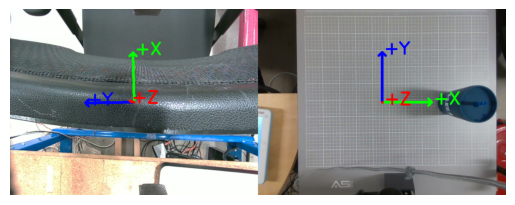

In [271]:
pcd_wkspc, rgbd_wkspc = wkspc.getPCD()
pcd_wrist, rgbd_wrist = wrist.getPCD()
img_wrist = np.array(rgbd_wrist.color)
img_wkspc = np.array(rgbd_wkspc.color)

R_cw = np.array([ # camera to wrist
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
])
R_wkspc = np.array([[1, 0, 0], [0, -1, 0], [0, 0, -1]])
T_wr = np.array(robot.getPose())
R_wr = T_wr[:3, :3]
R_cr = R_cw @ R_wr.T
intrinsics = np.load("scalingforce/intrinsic_matrix.npy", allow_pickle=True)
img_wrist_labeled = label_wrist_image_rotation_axes(img_wrist.copy(), R_cw, intrinsics, axis_length=0.03)
img_wrist_labeled_base = label_wrist_image_rotation_axes(img_wrist.copy(), R_cr, intrinsics, axis_length=0.03)
img_wkspc_labeled = label_wrist_image_rotation_axes(img_wkspc.copy(), R_wkspc, intrinsics, axis_length=0.03)
world_only = np.hstack((img_wrist_labeled_base, img_wkspc_labeled))
wrist_only = np.hstack((img_wkspc_labeled, img_wrist_labeled))
world_wrist = np.hstack((img_wrist_labeled_base, img_wkspc_labeled, img_wrist_labeled))
prev_img = wrist_only.copy()
# save img
fn = f"{LOG_NAME}/init_axes_{user_query}.png"
cv2.imwrite(fn, cv2.cvtColor(world_only, cv2.COLOR_RGB2BGR))

plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.imshow(world_only)

In [272]:
reload_modules(sf_force_thinker, sf_grasp_selection, sf_position_thinker, conversation, sf_force_reflection)
from magpie_prompts.conversation import openai_encode_image, build_messages, send_message
# MESSAGES, RESPONSES, MOTION_PLANS = [], [], []
MESSAGES, RESPONSES, MOTION_PLANS, MOTION_REPORTS = [], [], [], []
prompt_config = {
    "obj": grasp_phrase,
    "task": user_query
}
prompt_config = {**prompt_config, **direction_dict}

img = Image.fromarray(world_only)
prompt = sf_force_thinker.prompt_base_frame_thinker.format(**prompt_config)
MESSAGES = build_messages(prompt, img, messages=MESSAGES, model_type=model_type)
response = send_message(client, model, MESSAGES, model_type=model_type)
motion_plan = force_thinker.process_thinker_response(response)
print(response)

# Log messages
MESSAGES = build_messages(response, image=None, messages=MESSAGES, model_type=model_type, role="assistant")
RESPONSES = build_messages(response, image=None, messages=RESPONSES, model_type=model_type)

# Compute wrist-frame vectors
def construct_wrist_frame(plan, pose):
    wrench_base = plan['ft_vector']
    wrench_wrist = transform_6d(wrench_base, pose, pose_to_origin=False, is_wrench=True)
    p_base = plan['world_motion_vector']
    p_wrist = R_wr.T @ p_base
    plan['wrist_motion_vector'] = p_wrist
    plan['wrist_wrench'] = wrench_wrist
    return plan

motion_plan = construct_wrist_frame(motion_plan, T_wr)

MOTION_PLANS = build_messages(motion_plan, image=None, messages=MOTION_PLANS, model_type=model_type)
print(motion_plan)

# Save
np.save(f"{LOG_NAME}/motion_response-{STEP}.npy", response, allow_pickle=True)
np.save(f"{LOG_NAME}/motion_plan-{STEP}.npy", motion_plan, allow_pickle=True)

motion_plan

[start of motion plan]
The task is to turn the black wheeled chair to face forward while grasping the Textured black seat rim.

Understanding Object-Centric Motion in the World Frame:
The provided images in the two-part image confirm the presence of a black wheeled chair with a textured black seat rim. The task requires rotating the chair to face forward.
The red axis representing the world Z-axis corresponds to upward and downward motion in the world. 
To complete the task, the object in the image should have no linear motion along the Z-axis with magnitude 0 meters.
The green axis representing the world X-axis corresponds to left and right motion in the world, relative to the robot. 
To complete the task, the object in the image should have no linear motion along the X-axis with magnitude 0 meters.
The blue axis representing the world Y-axis corresponds to backward and forward motion in the world, relative to the robot. 
To complete the task, the object in the image should have no li

{'property_description': 'Black wheeled chair with textured black seat rim, mass approximately 10 kg, rubber gripper, static friction coefficient of 0.8 with seat rim, 0.6 with floor.',
 'world_motion_description': 'Rotate the chair around the Z-axis to face forward while maintaining position in the X, Y, and Z axes.',
 'world_motion_direction': [0, 0, 0],
 'world_motion_magnitude': [0.0, 0.0, 0.0],
 'world_motion_vector': [0.0, 0.0, 0.0],
 'ft_description': 'No forces in X, Y, Z axes. No torques around X and Y axes. Apply approximately 5 Nm torque around Z-axis to rotate the chair.',
 'ft_magnitude': [0.0, 0.0, 0.0, 0.0, 0.0, 5.0],
 'ft_vector': [0.0, 0.0, 0.0, 0.0, 0.0, 5.0],
 'grasp_force': 7.5,
 'duration': 5,
 'wrist_motion_vector': array([0., 0., 0.]),
 'wrist_wrench': array([ 0.   ,  0.   ,  0.   , -0.105,  0.324, -4.988])}

In [266]:
robot.ctrl.disconnect()

In [267]:
robot.ctrl.reconnect()
robot.toggle_teach_mode()


In [270]:
robot.toggle_teach_mode()

# Robot Motion Execution

In [265]:
G.reset_parameters()

In [232]:
STEP -= 1

In [273]:
importlib.reload(ur5)
importlib.reload(gripper)
robot.start_ft_sensor(poll_rate=100)
G = robot.gripper
# G.reset_parameters()
# np.save(f"{LOG_NAME}/init_home.npy", robot.home)
# pose = np.load(f"{LOG_NAME}/init_moveto_pose.npy")
G.reset_and_close_gripper(force_limit=10)
time.sleep(0.375)
camera_dict = {
    wrist: "record/wrist/",
    wkspc: "record/workspace/"
}

In [ ]:
robot.speedL_TCP(np.array([ 0.   ,  0.   ,  0.   , -0.007,  0.022, -0.333]))

In [ ]:
robot.speedL_TCP(np.zeros(6))

In [277]:
init_cmd

array([ 0.   ,  0.   ,  0.   , -0.007,  0.022, -0.333])

In [274]:
# Execute motion plan
import numpy as np
motion_plan = np.load(f"{LOG_NAME}/motion_plan-{STEP}.npy", allow_pickle=True).item()
goal_delta = np.array(motion_plan["wrist_motion_vector"])
wrench = np.array(motion_plan['wrist_wrench'])
wrench_goal = wrench * -1
# wrench_goal = wrench
init_cmd = np.hstack((wrench[:3] / 100, wrench[3:] / 15))
duration = motion_plan['duration']
grasp_force = motion_plan['grasp_force']
P = 0.0003 # stiffness gain, default is 0.0005
print(init_cmd)
print(wrench_goal)

robot.start_ft_sensor()
motion_log = await robot.concurrent_gripper_camera_robot_control(wrench=wrench_goal, goal_delta=goal_delta, grasp_force=grasp_force, 
                                         camera_dict=camera_dict, init_cmd=init_cmd, tolerance=0.00, rerun_viz=rerun_viz,
                                        #  camera_dict=camera_dict, init_cmd=init_cmd, tolerance=0.00, rerun_viz=None,
                                        #  duration=duration, p=P, control_type="bang_bang")
                                         duration=duration, p=P, control_type="proportional")
robot.ctrl.speedL([0.00, -0.00, 0.00, 0.0, 0.0, 0.0], 0.5, 0.25)
STEP += 1

[ 0.     0.     0.    -0.007  0.022 -0.333]
[-0.    -0.    -0.     0.105 -0.324  4.988]
D405 Recording Started
D435 Recording Started
D405 Recording Task Cancelled
D405 Recording Stopped
D435 Recording Task Cancelled
D435 Recording Stopped


In [276]:
motion_log

{'gripper': {1745282727.837811: {'cf_l': 3.731875390000001,
   'cf_r': 3.762435040000001,
   'cf': 7.494310430000002,
   'aperture': 25.27711898121891,
   'af': 7.5},
  1745282727.9659102: {'cf_l': 3.731875390000001,
   'cf_r': 3.762435040000001,
   'cf': 7.494310430000002,
   'aperture': 25.27711898121891,
   'af': 7.5},
  1745282728.13355: {'cf_l': 3.731875390000001,
   'cf_r': 3.762435040000001,
   'cf': 7.494310430000002,
   'aperture': 25.27711898121891,
   'af': 7.5},
  1745282728.3003879: {'cf_l': 3.731875390000001,
   'cf_r': 3.762435040000001,
   'cf': 7.494310430000002,
   'aperture': 25.27711898121891,
   'af': 7.5},
  1745282728.4672573: {'cf_l': 3.731875390000001,
   'cf_r': 3.762435040000001,
   'cf': 7.494310430000002,
   'aperture': 25.27711898121891,
   'af': 7.5},
  1745282728.6346319: {'cf_l': 3.731875390000001,
   'cf_r': 3.762435040000001,
   'cf': 7.494310430000002,
   'aperture': 25.27711898121891,
   'af': 7.5},
  1745282728.801192: {'cf_l': 3.731875390000001,
 

In [275]:
# SAVE
episode_time = time.time()
episode_name = f"{LOG_NAME}/episode_{STEP}_{episode_time}"

if SAVE:
    import time
    import os
    if not os.path.exists(episode_name):
        os.makedirs(episode_name)
    messages = [i for i in MESSAGES if type(i) == str]
    # create directory if it doesn't exist
    np.save(f"{episode_name}/query_image.npy", prev_img, allow_pickle=True)
    np.save(f"{episode_name}/messages.npy", messages, allow_pickle=True)
    np.save(f"{episode_name}/gripper_log.npy", motion_log['gripper'],allow_pickle=True)
    np.save(f"{episode_name}/robot_log.npy", motion_log['robot'],allow_pickle=True)
    np.save(f"{episode_name}/wrist_log.npy", motion_log['record/wrist/'],allow_pickle=True)
    np.save(f"{episode_name}/wkspc_log.npy", motion_log['record/workspace/'],allow_pickle=True)
if LOAD:
    motion_log['gripper'] = np.load(f"{episode_name}/gripper_log.npy", allow_pickle=True).item()
    motion_log['robot'] = np.load(f"{episode_name}/robot_log.npy", allow_pickle=True).item()
    pos_msg = np.load(f"{episode_name}/messages.npy", allow_pickle=True)
    query_image = np.load(f"{episode_name}/query_image.npy", allow_pickle=True)
    # query_image = Image.fromarray(query_image).convert("RGB")
    prev_img = query_image.copy()
    feedback_img_fn = f"{LOG_NAME}/axes_step-0_tip the bottle onto its edge.png"
    feedback_img = np.array(Image.open(feedback_img_fn))
    prompt_config = {
        "obj": "the top of the bottle",
        "task": "tip the bottle onto its edge",
    }
    
for key in motion_log:
    ts = motion_log[key].keys()
    last_ts = sorted(ts)[-1]
    first_ts = sorted(ts)[0]
    print(f"sensor {key} first timestamp: {first_ts}")
    print(f"sensor {key} last timestamp: {last_ts}")
    duration = last_ts - first_ts
    length = len(motion_log[key])
    print(f"sensor {key} duration: {duration}, length: {length}, Hz: {length/duration}\n")

if LOAD:
    plt.xticks([])
    plt.yticks([])
    plt.axis('off')
    plt.imshow(query_image)
    plt.imshow(feedback_img)


sensor gripper first timestamp: 1745282727.837811
sensor gripper last timestamp: 1745282732.811175
sensor gripper duration: 4.9733641147613525, length: 31, Hz: 6.233205388680362



IndexError: list index out of range

# Feedback

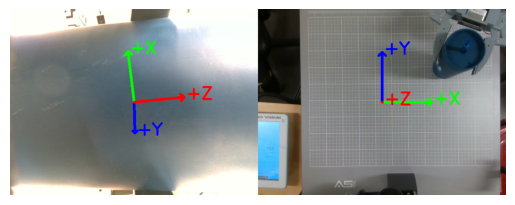

In [244]:
gripper_log  = motion_log['gripper'].copy()
robot_log    = motion_log['robot'].copy()
gripper_ts   = sorted(gripper_log.keys())
robot_ts     = sorted(robot_log.keys())

wrist_log    = motion_log['record/wrist/']
wkspc_log    = motion_log['record/workspace/']
wrist_ts     = sorted(wrist_log.keys())
wkspc_ts     = sorted(wkspc_log.keys())

R_cw = np.array([ # camera to wrist
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
])
T_wr = np.array(sm.SE3(poses.pose_vec_to_mtrx(np.array(robot_log[robot_ts[-1]]['actual_TCP_pose']))))
R_wr = T_wr[:3, :3]
R_cr = R_cw @ R_wr.T
intrinsics = np.load("scalingforce/intrinsic_matrix.npy", allow_pickle=True)
img_wrist_final = wrist_log[wrist_ts[-1]]['rgb']
img_wkspc_final = wkspc_log[wkspc_ts[-1]]['rgb']
img_wrist_final_labeled = label_wrist_image_rotation_axes(img_wrist_final.copy(), R_cw, intrinsics, axis_length=0.03)
img_wrist_final_labeled_base = label_wrist_image_rotation_axes(img_wrist_final.copy(), R_cr, intrinsics, axis_length=0.03)
img_wkspc_final_labeled = label_wrist_image_rotation_axes(img_wkspc_final.copy(), R_wkspc, intrinsics, axis_length=0.03)
feedback_position_img = np.hstack((img_wrist_final_labeled_base, img_wkspc_final_labeled))
feedback_img = np.hstack((img_wrist_final_labeled_base, img_wkspc_final_labeled))

# save img
np.save(f"{episode_name}/after_image.npy", feedback_img, allow_pickle=True)
fn = f"{episode_name}/after_image.png"
cv2.imwrite(fn, cv2.cvtColor(feedback_img, cv2.COLOR_RGB2BGR))

plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.imshow(feedback_img)

In [245]:
human_feedback = ""

In [246]:
from spatialmath.base import rodrigues, tr2rpy
import numpy as np

motion_report = ""
motion_report += f"Task: {user_query} while grasping {grasp_phrase}\n"
motion_report += f"Human Feedback: {human_feedback}\n"
motion_report += f"Initial Motion Plan: {motion_plan}\n"
# get first and last TCP pose of robot log
first_pose = np.array(robot_log[robot_ts[0]]['actual_TCP_pose'])
last_pose =  np.array(robot_log[robot_ts[-1]]['actual_TCP_pose'])
dist =  last_pose - first_pose
# get the rotation matrix from the wrist frame to the robot frame
# rot = rodrigues(first_pose[3:6])
# transform distance to be relative to the first TCP wrist frame, use inverse of rot
# dist_wrist = rot.T @ dist[:3]
# motion_report += f"Motion Plan Results: \nDistance traveled relative to original wrist base frame [x, y, z] (m) axes: {dist_wrist.round(3)}\n"
motion_report += f"Distance traveled along base frame [x, y, z] (m) axes: {dist[:3].round(3)}\n"

# Use a simple moving average with a window size of downsample_factor
def moving_average(data, window_size):
    return np.array([np.mean(data[i:i+window_size], axis=0) for i in range(0, len(data), window_size)])

def get_report(desired_freq, timestamps, log, name, description):
    log_dur = timestamps[-1] - timestamps[0]
    log_flat = np.array([log[i][name] for i in timestamps])
    num_downsampled_entries = int(log_dur // (1 / desired_freq))
    downsample_factor = len(timestamps) // num_downsampled_entries
    downsampled_log = moving_average(log_flat, downsample_factor)
    summary = f"\n{description} Log Summary:"
    summary += f"\nMotion Duration: {log_dur}s"
    summary += f"\nAverage {name} Downsampled at {desired_freq}Hz:"
    for i, entry in enumerate(downsampled_log):
        summary += f"\n{i*(1/desired_freq)}s to {(i+1)*(1/desired_freq)}: {entry.round(2)}"
    summary += f"\nOverall Average Across Episode: {np.mean(downsampled_log, axis=0).round(2)}"
    return summary
desired_freq = 2

# flip the sign of all the wrenches because LLMs do not understand action/reaction
for i in robot_ts:
    wrench = np.array(robot_log[i]['wrench'])
    T = sm.SE3(poses.pose_vec_to_mtrx(np.array(robot_log[i]['actual_TCP_pose']))).A
    base_wrench = transform_6d(wrench, T, pose_to_origin=True, is_wrench=True)
    robot_log[i]['base_wrench'] = -1 * base_wrench
    robot_log[i]['wrench'] = -1 * wrench

base_wrench_report = get_report(desired_freq, robot_ts, robot_log, "base_wrench", "6D Base Frame Wrench [x, y, z, rx, ry, rz] (N and Nm)")
motion_report += f"{base_wrench_report}\n"

wrench_report = get_report(desired_freq, robot_ts, robot_log, "wrench", "6D Wrench [x, y, z, rx, ry, rz] (N and Nm)")
# motion_report += f"{wrench_report}\n"

gripper_report = get_report(desired_freq, gripper_ts, gripper_log, "cf", "Gripper Contact Force (N)")
# gripper_report = get_report(desired_freq, gripper_ts, gripper_log, "cf_l", "Left Gripper Contact Force (N)")
motion_report += f"{gripper_report}\n"
# gripper_report = get_report(desired_freq, gripper_ts, gripper_log, "cf_r", "Right Gripper Contact Force (N)")
# print(gripper_report)
# motion_report += f"{gripper_report}\n"
print(motion_report)
if SAVE:
    with open(f"{episode_name}/motion_report.txt", "w") as f:
        f.write(motion_report)
    np.save(f"{episode_name}/motion_report.npy", motion_report, allow_pickle=True)



Task: tip the bottle forward onto its edge while grasping back of blue bottle
Human Feedback: 
Initial Motion Plan: {'property_description': 'Partially filled blue plastic bottle, mass 0.5 kg, static friction 0.4 (gripper), 0.3 (table).', 'world_motion_reflection': 'Move forward 3cm, rotate forward about X to tip onto edge. Increase torque about X axis, reduce negative force applied in Z axis by reducing forward motion.', 'world_motion_direction': [0, -1, 0], 'world_motion_magnitude': [0.0, 0.03, 0.0], 'world_motion_vector': [0.0, -0.03, 0.0], 'ft_description': 'Push forward with 2N, rotate clockwise about X with 0.5Nm, avoid negative Z force.', 'ft_magnitude': [0.0, 2.0, 1.0, 0.5, 0.0, 0.0], 'ft_vector': [0.0, -2.0, 1.0, -0.5, 0.0, 0.0], 'grasp_force': 7.5, 'duration': 2.0, 'wrist_motion_vector': array([-0.014, -0.002,  0.026]), 'wrist_wrench': array([-0.987, -1.129,  1.659,  0.508, -0.054,  0.265])}
Distance traveled along base frame [x, y, z] (m) axes: [ 0.007 -0.059  0.014]

6D Bas

In [247]:
from magpie_prompts.prompts import sf_force_thinker, sf_grasp_selection, sf_force_reflection, sf_position_thinker
from magpie_prompts import conversation
reload_modules(sf_force_thinker, sf_grasp_selection, sf_position_thinker, conversation, sf_force_reflection)
from magpie_prompts.conversation import openai_encode_image, build_messages, send_message

feedback_messages = MOTION_REPORTS.copy()
MOTION_REPORTS = build_messages(motion_report, image=None, messages=MOTION_REPORTS, model_type=model_type)
feedback_prompt_config = prompt_config.copy()
feedback_prompt_config['motion_report'] = motion_report
feedback_prompt_config['human_feedback'] = human_feedback
feedback_prompt = sf_force_reflection.prompt_base_frame_reflector.format(**feedback_prompt_config)
img_feedback_PIL = Image.fromarray(feedback_img).convert("RGB")
img_previous_PIL = Image.fromarray(prev_img).convert("RGB")
prev_img = feedback_img

MESSAGES = build_messages(feedback_prompt, img_feedback_PIL, messages=MESSAGES, model_type=model_type)
feedback_messages = build_messages("This is the previous image, taken prior to execution of the robot motion plan", 
                                   img_previous_PIL, messages=feedback_messages, model_type=model_type)
feedback_messages = build_messages(feedback_prompt, img_feedback_PIL, messages=feedback_messages, model_type=model_type)
feedback_response = send_message(client, model, feedback_messages, model_type=model_type)
MESSAGES = build_messages(feedback_response, image=None, messages=MESSAGES, model_type=model_type, role="assistant")
RESPONSES = build_messages(feedback_response, image=None, messages=RESPONSES, model_type=model_type)

print(feedback_response)
force_reflector = sf_force_reflection.PromptForceReflection()
motion_feedback_plan = force_reflector.process_thinker_response(feedback_response)
motion_feedback_plan = construct_wrist_frame(motion_feedback_plan, robot.getPose().A)
MOTION_PLANS = build_messages(motion_feedback_plan, image=None, messages=MOTION_PLANS, model_type=model_type)
np.save(f"{LOG_NAME}/response-{STEP}.npy", feedback_response, allow_pickle=True)
np.save(f"{LOG_NAME}/motion_plan-{STEP}.npy", motion_feedback_plan, allow_pickle=True)
motion_feedback_plan


[beginning of reflection]
The task is to tip the bottle forward onto its edge while grasping the back of blue bottle.

Assessing Object-Centric Motion in the World Frame:
The provided images in the two-part image confirm the presence of a blue bottle grasped by the robot, situated on a table with a grid.
The red axis representing the world Z-axis corresponds to upward and downward motion in the world. 
The change in the world Z-axis position was incorrect relative to the estimated position goal because the bottle should not have moved significantly vertically.
The green axis representing the world X-axis corresponds to left and right motion in the world, relative to the robot. 
The change in the world X-axis position was correct relative to the estimated position goal because a small amount of movement is expected as the bottle rotates.
The blue axis representing the world Y-axis corresponds to backward and forward motion in the world, relative to the robot. 
The change in the world Y-

{'property_description': 'Partially filled blue plastic bottle, mass 0.5 kg, static friction 0.4 (gripper), 0.3 (table).',
 'world_motion_reflection': 'Move forward more (5cm), and apply more torque about the X axis (0.7 Nm) to tip the bottle onto its edge. Increase Y force slightly (3N).',
 'world_motion_direction': [0, -1, 0],
 'world_motion_magnitude': [0.0, 0.05, 0.0],
 'world_motion_vector': [0.0, -0.05, 0.0],
 'ft_description': 'Push forward with 3N, rotate clockwise about X with 0.7Nm, avoid negative Z force.',
 'ft_magnitude': [0.0, 3.0, 0.0, 0.7, 0.0, 0.0],
 'ft_vector': [0.0, -3.0, 0.0, -0.7, 0.0, 0.0],
 'grasp_force': 7.5,
 'duration': 2.0,
 'wrist_motion_vector': array([-0.023,  0.   ,  0.044]),
 'wrist_wrench': array([-1.365,  0.061,  2.671,  1.254, -0.167,  0.644])}